In [1]:
import pandas as pd
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
folder_dir = r'/content/drive/MyDrive/IIMT/'

In [ ]:
train_embed_file_path = folder_dir+'notebook-output/day-2/train-124-embd-reduced.csv'   # training reduced embedding dataframe
train_biophysical_file_path = folder_dir+'notebook-output/day-2/train-124-biophysical-curated.csv'   # training curated biophysical parameters dataframe

In [5]:
train_embed_df = pd.read_csv(train_embed_file_path)
train_biophysical_df = pd.read_csv(train_biophysical_file_path)

In [6]:
set(train_embed_df.columns.tolist()).intersection(train_biophysical_df.columns.tolist())

{'Class', 'Sequence'}

In [7]:
train_combined_df = pd.merge(train_biophysical_df, train_embed_df, on=['Sequence', 'Class'])
train_combined_df

,Sequence,Class,MW,Length,pI,GRAVY,Aromaticity,InstabilityIndex,BomanIndex,HelixFraction,...,reduced_66,reduced_67,reduced_68,reduced_69,reduced_70,reduced_71,reduced_72,reduced_73,reduced_74,reduced_75
0,MDRELRTPPELEGVDWYDDAPRRPRPIVTLVAWIAILGLVLSVGAG...,NAMP,5680.536,51,4.660,0.3059,0.0980,36.039,0.918,0.2941,...,0.669405,0.366264,0.731877,-0.691801,1.485709,-0.077118,0.652254,-0.204326,0.335480,-1.858368
1,MIMGFIDQMRAKGHAVESICRVLRQEGCQIAARTYRAWRRRSASAR...,AMP,10555.054,95,11.393,-0.5105,0.0526,49.583,2.805,0.2421,...,-0.711868,1.348849,-0.515823,0.488626,-0.038214,-0.303245,-0.384725,1.551493,1.422169,0.050939
2,VNFALDGRNYEIDLSKEHAAELREFLKPYMKKGRAVAPPSPKVEAA...,AMP,9084.225,79,9.845,-0.8975,0.0886,28.275,2.809,0.4177,...,-2.637391,2.056007,-1.462979,2.265712,-1.544559,4.208980,1.783836,-0.534014,-1.828399,2.422759
3,MSTRRPAHQPTRGTAAPRGFVSPWEHGSRLYRTLVLTGSALFLVGI...,AMP,10225.734,97,12.000,0.0474,0.0515,37.009,1.523,0.2680,...,0.246369,-0.736285,-1.051716,-0.165886,1.357880,-0.751707,-2.555225,-0.236983,-0.452529,1.082228
4,MLHHHAITVLAALRALIHDDVRDERGDVPGWVMITLMSAVLVAGLL...,NAMP,7193.380,68,5.977,0.7044,0.0294,38.832,0.090,0.3824,...,0.016582,-2.493353,-0.601509,3.190476,0.294998,-0.188588,1.615609,2.333886,-0.531257,1.537423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119,MDWRSKAACLDKDPELFFPVGNTGPALLQIEEAKAVCRSCEVVDTC...,AMP,9134.347,82,7.644,-0.5439,0.0610,87.666,2.470,0.3902,...,-0.540990,1.058694,1.499774,-0.061568,-0.013023,0.789761,-1.346470,0.483677,-1.256006,0.670450
120,MGNTLGFLRGVDRLHAFYTENVRMLAHAYDLTDEEASELLANTGFT...,AMP,9979.817,93,4.340,-0.4763,0.0538,33.912,2.085,0.3226,...,-2.052671,-0.974446,-0.357233,-0.149569,-0.108186,1.457276,1.213332,0.899477,-0.940176,-1.401219
121,MSIVQIDVEDLRAKSGAVEGSIGRLQAEVSTMEANLRQLQDTWRGQ...,AMP,10604.710,96,4.850,-0.3802,0.0625,36.527,2.218,0.3750,...,-0.752916,-0.326105,-2.832087,0.391301,0.062245,-1.379025,-0.214759,-0.613155,-2.071988,1.120916
122,VKTFDELYAELTRKVQERPEGSGTVAQIDAGVHAIGKKVVEEAAEV...,AMP,9722.822,87,4.625,-0.2207,0.0690,35.797,1.570,0.4368,...,-1.258834,1.049107,-1.775288,0.291623,-1.453113,0.066654,2.631179,-0.810807,0.366343,-1.255364


In [8]:
from scipy.stats import zscore

train_combined_copydf = train_combined_df.copy()
cols_to_stdise = [col for col in train_combined_copydf.columns if col not in ['Sequence', 'Class']]
for col in cols_to_stdise :
    train_combined_copydf[col] = zscore(train_combined_copydf[col])

In [9]:
save_dir = folder_dir+'notebook-output/day-3/'
os.makedirs(save_dir, exist_ok=True)

In [10]:
train_combined_copydf.to_csv(save_dir+'final-train-df.csv', index=False)

In [ ]:
test_embed_file_path = folder_dir+'notebook-output/day-2/test-32-embd-reduced.csv'   # test reduced embedding dataframe
test_biophysical_file_path = folder_dir+'notebook-output/day-2/test-32-biophysical-curated.csv'   # test curated biophysical parameters dataframe

In [12]:
test_embed_df = pd.read_csv(test_embed_file_path)
test_biophysical_df = pd.read_csv(test_biophysical_file_path)

In [13]:
test_combined_df = pd.merge(test_biophysical_df, test_embed_df, on=['Sequence', 'Class'])
test_combined_df

,Sequence,Class,MW,Length,pI,GRAVY,Aromaticity,InstabilityIndex,BomanIndex,HelixFraction,...,reduced_66,reduced_67,reduced_68,reduced_69,reduced_70,reduced_71,reduced_72,reduced_73,reduced_74,reduced_75
0,MSGPTCRHCADWAYGYAEGYAQGHASGLAAGRVQGAAEGPAHPAIA...,AMP,9115.823,88,5.861,-0.3205,0.1023,30.797,1.438,0.3636,...,-0.053961,0.504478,1.010648,0.613564,-0.394494,-0.343950,0.255611,1.327752,-0.125223,-0.760744
1,MSVSIKPLEDRIVVRPLEAEQTTASGLVIPDTAKEKPQEGQVVAVG...,AMP,10345.661,98,4.783,-0.0480,0.0306,18.347,1.302,0.3265,...,2.628995,-2.233326,1.442686,-0.766219,-1.873193,0.764581,1.033506,0.935495,0.209494,1.136067
2,MSIRYPLGYVENERKVYPQGYARERVSPGGDGEGRHDQETSPGGVS...,NAMP,7629.405,68,9.804,-1.0279,0.0735,52.481,2.826,0.1912,...,1.677872,2.867895,-1.250012,-1.144773,2.470776,-0.014847,1.269453,1.030637,0.577203,-0.823122
3,MTAQLSSNAPRPRDSSAYVTVHSRGGQKVFVRDAAKRETLRRADAL...,NAMP,7458.320,68,11.598,-0.8279,0.0294,60.772,3.389,0.3235,...,-0.535639,-0.298609,-0.882494,-0.267927,-0.717203,0.359446,-0.453839,-1.431759,0.786361,1.461195
4,MADQQIPETKNSDAPGDQDQAAQQAPAEVDGLAAKAEQSEKETEEN...,NAMP,5600.698,53,4.050,-1.4321,0.0189,56.709,2.925,0.4151,...,0.044666,1.719665,0.468308,0.084006,-2.413136,1.126437,1.113813,3.051061,0.001321,-0.479505
5,MYSVYAQHWQRDTEAAASARVYRVSRLRHDAAPAPGVSIFRHGRPV...,AMP,9139.141,81,9.954,-0.7136,0.0617,38.244,2.873,0.2840,...,-0.870418,-0.617546,-0.038761,0.331497,0.451061,0.300469,-0.230248,-1.231554,0.433816,1.223822
6,MADLAGISDATVRQIERSTGRGTLSSLLAVLGVLGLDLEARR,NAMP,4382.995,42,6.002,0.2881,0.0000,46.326,1.519,0.3810,...,1.503475,0.420405,-2.363405,-0.897046,1.019098,-0.711314,-0.822904,1.057037,0.574942,1.891411
7,MTTQQQTVTIPAGFAPEQIPLIEGKSETFISYQGPASGHVST,NAMP,4448.914,42,4.750,-0.2071,0.0714,51.505,0.889,0.2143,...,1.805006,1.401111,1.311694,-2.232236,-1.729945,-0.880585,-0.072529,0.892683,1.127513,-0.253343
8,MQLLLALAYIALTVVLAALTVRIVLDVTQSFVRHWRPTGAALMLAS...,AMP,10327.465,98,11.271,1.3112,0.0612,29.641,-0.637,0.3673,...,1.101577,0.253701,-2.749590,0.771936,1.485661,1.502878,0.755848,0.160017,-1.593165,0.583959
9,MLKAISSMGIKSDHMYAAGLASVGLSWVAWAVSRFGADEPKPQADR...,NAMP,8339.497,77,8.121,0.0013,0.1039,26.639,0.814,0.4156,...,-0.779772,0.316043,-0.535560,0.484265,-0.250028,-1.168382,0.068280,-0.613923,-1.853556,0.653127


## Logistic Regression

**Setup:** `StandardScaler` + `LogisticRegression` in one `Pipeline` (so scaling is refit per CV fold, never leaking test-fold statistics), tuned via `GridSearchCV` over L1/L2/elasticnet penalties and a range of `C` values, using 5-fold `StratifiedKFold` scored on MCC.

**Selected model (`best_lr`):** `C=0.1`, `penalty='l1'` — best inner CV MCC = **0.608 ± 0.087**. Fold-to-fold scores ranged from 0.45 to 0.688, a fairly wide spread given only 124 training rows split 5 ways.

**Held-out test set (32 rows):**

| Metric | Value |
|---|---|
| Accuracy | 0.906 |
| Balanced Accuracy | 0.875 |
| MCC | 0.808 |
| F1 | 0.857 |
| ROC-AUC | 0.975 |
| PR-AUC | 0.961 |

Confusion matrix: **0** false positives, **3** false negatives — every NAMP prediction was correct, but the model missed 3 of 12 true AMPs (75% AMP recall).

*Note: test MCC (0.808) came in noticeably higher than the inner CV MCC (0.608 ± 0.087). With only 32 test rows, this is plausibly the test split being "easier" by chance rather than the model generalizing better than CV suggested — the inner CV distribution is the more trustworthy signal of how stable this model actually is.*

In [14]:
"""
Train a Logistic Regression AMP/NAMP classifier with K-fold CV
hyperparameter tuning on the training set, then evaluate once on
the held-out test set.

Assumes:
  - train_df: 124 rows x 97 columns
  - test_df:  32 rows x 97 columns
  - Both contain 'Sequence', 'Class' (AMP/NAMP label), 19 biophysical
    params, and 76 PCA-reduced embedding components.
  - Scaling is fit on training folds only (inside the CV pipeline),
    never on the full training set before CV, to avoid leakage.
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

RANDOM_STATE = 42
NON_FEATURE_COLS = ["Sequence", "Class"]


def prepare_X_y(df, label_map=None):
    """
    Split a dataframe into feature matrix X and binary label vector y.
    label_map lets you fix which class is 1 (e.g. {'AMP': 1, 'NAMP': 0}).
    """
    X = df.drop(columns=NON_FEATURE_COLS)
    if label_map is None:
        label_map = {"AMP": 1, "NAMP": 0}
    y = df["Class"].map(label_map)
    if y.isna().any():
        raise ValueError(
            f"Unmapped class labels found: {df['Class'][y.isna()].unique()}. "
            f"Update label_map to cover all values."
        )
    return X, y.astype(int)


def build_search_pipeline(random_state=RANDOM_STATE):
    """
    StandardScaler + LogisticRegression in one Pipeline so that scaling
    is refit on each CV training fold rather than leaking test-fold
    statistics into the scaler.
    """
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="saga",       # supports l1, l2, and elasticnet penalties
            max_iter=5000,
            random_state=random_state,
        )),
    ])

    # Modest grid given N=124 in training set - avoid over-tuning on
    # a small dataset. Covers both regularization strength and type.
    param_grid = [
        {
            "clf__penalty": ["l2"],
            "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
        },
        {
            "clf__penalty": ["l1"],
            "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
        },
        {
            "clf__penalty": ["elasticnet"],
            "clf__C": [0.01, 0.1, 1, 10],
            "clf__l1_ratio": [0.25, 0.5, 0.75],
        },
    ]
    return pipeline, param_grid


def tune_logreg(X_train, y_train, n_splits=5, scoring="matthews_corrcoef", random_state=RANDOM_STATE):
    """
    Run GridSearchCV with StratifiedKFold over the training set only.
    Returns the fitted GridSearchCV object (best_estimator_ is already
    refit on the full training set with the winning hyperparameters).
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    pipeline, param_grid = build_search_pipeline(random_state)

    # matthews_corrcoef is a good default for imbalanced binary classification;
    # swap scoring="roc_auc" or "average_precision" if you prefer those instead.
    scorer = "matthews_corrcoef" if scoring == "matthews_corrcoef" else scoring

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scorer,
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    grid_search.fit(X_train, y_train)
    return grid_search, cv


def report_cv_performance(best_pipeline, X_train, y_train, cv, scoring="matthews_corrcoef"):
    """Print CV score distribution for the selected model (not just the mean)."""
    scores = cross_val_score(best_pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    print(f"\nInner CV {scoring} scores per fold: {np.round(scores, 3)}")
    print(f"Inner CV {scoring}: {scores.mean():.3f} +/- {scores.std():.3f}")


def evaluate_on_test(best_pipeline, X_test, y_test):
    """Evaluate the final fitted pipeline once on the held-out test set."""
    y_pred = best_pipeline.predict(X_test)
    y_proba = best_pipeline.predict_proba(X_test)[:, 1]

    print("\n=== Held-out test set performance (evaluated once) ===")
    print(f"Accuracy:          {accuracy_score(y_test, y_pred):.3f}")
    print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")
    print(f"MCC:               {matthews_corrcoef(y_test, y_pred):.3f}")
    print(f"F1:                {f1_score(y_test, y_pred):.3f}")
    print(f"ROC-AUC:           {roc_auc_score(y_test, y_proba):.3f}")
    print(f"PR-AUC (AP):       {average_precision_score(y_test, y_proba):.3f}")

    print("\nConfusion matrix (rows=true, cols=pred, order=[NAMP, AMP]):")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=["NAMP", "AMP"]))

In [15]:
label_map = {"AMP": 1, "NAMP": 0}
X_train, y_train = prepare_X_y(train_combined_df, label_map)
X_test, y_test = prepare_X_y(test_combined_df, label_map)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts()}")

# 1. Tune C / penalty via StratifiedKFold CV on the training set only
grid_search, cv = tune_logreg(X_train, y_train, n_splits=5)
print(f"\nBest params: {grid_search.best_params_}")
print(f"Best inner CV score (matthews_corrcoef): {grid_search.best_score_:.3f}")

best_lr = grid_search.best_estimator_  # already refit on full X_train

# 2. Report the CV score distribution for the chosen model, not just
#    the single mean picked during search - useful given N=124.
report_cv_performance(best_lr, X_train, y_train, cv)

# 3. Evaluate exactly once on the held-out test set
evaluate_on_test(best_lr, X_test, y_test)

Train: (124, 95), Test: (32, 95)
Train class balance:
Class
0    76
1    48
Name: count, dtype: int64

Best params: {'clf__C': 0.1, 'clf__penalty': 'l1'}
Best inner CV score (matthews_corrcoef): 0.608

Inner CV matthews_corrcoef scores per fold: [0.653 0.667 0.582 0.688 0.45 ]
Inner CV matthews_corrcoef: 0.608 +/- 0.087

=== Held-out test set performance (evaluated once) ===
Accuracy:          0.906
Balanced accuracy: 0.875
MCC:               0.808
F1:                0.857
ROC-AUC:           0.975
PR-AUC (AP):       0.961

Confusion matrix (rows=true, cols=pred, order=[NAMP, AMP]):
[[20  0]
 [ 3  9]]

Classification report:
              precision    recall  f1-score   support

        NAMP       0.87      1.00      0.93        20
         AMP       1.00      0.75      0.86        12

    accuracy                           0.91        32
   macro avg       0.93      0.88      0.89        32
weighted avg       0.92      0.91      0.90        32



## XGBoost

**Setup:** no feature scaling needed (tree splits are scale-invariant). `scale_pos_weight` is computed automatically from the training class balance (76 NAMP / 48 AMP → ≈1.58) to handle the imbalance. Hyperparameters tuned via `RandomizedSearchCV` (60 iterations) over shallow, regularized trees — kept conservative given N=124 to limit overfitting risk.

**Selected model (`best_xgb`):** `max_depth=3`, `n_estimators=229`, `learning_rate≈0.283`, plus moderate L1/L2 regularization (`reg_alpha≈0.36`, `reg_lambda≈4.87`) — best inner CV MCC = **0.767 ± 0.072**, both higher and more stable across folds than Logistic Regression.

**Held-out test set (32 rows):**

| Metric | Value |
|---|---|
| Accuracy | 0.938 |
| Balanced Accuracy | 0.933 |
| MCC | 0.867 |
| F1 | 0.917 |
| ROC-AUC | 0.987 |
| PR-AUC | 0.983 |

Confusion matrix: 1 false positive, 1 false negative — the best-balanced result of the three models, and consistent with the highest and tightest inner CV score.

**Top features by gain importance:** `MW`, `reduced_15`, `Length`, `ShannonEntropy`, and `PositiveResidues_pct` dominate, with the two curated features `MW` and `Length` alone accounting for roughly a quarter of total importance. Worth double-checking whether this reflects genuine AMP biology (AMPs do tend to be shorter/lighter) versus a dataset-construction artifact, before treating `MW`/`Length` as confirmed signal — see the Pexiganan example later in this notebook, where this concentration on `Length`/`MW` may be part of why an actual AMP got misclassified.

In [16]:
"""
Train an XGBoost AMP/NAMP classifier with K-fold CV hyperparameter
tuning on the training set, then evaluate once on the held-out test set.

Mirrors train_logreg_cv.py's structure (same prepare_X_y, same
StratifiedKFold discipline, same "touch test set exactly once" rule),
adapted for XGBoost's larger hyperparameter space and the fact that
tree-based models don't need feature scaling.

Assumes:
  - train_df: 124 rows x 97 columns
  - test_df:  32 rows x 97 columns
  - Both contain 'Sequence', 'Class' (AMP/NAMP label), 19 biophysical
    params, and 76 PCA-reduced embedding components.
"""

import numpy as np
import pandas as pd
from scipy.stats import randint, uniform
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
NON_FEATURE_COLS = ["Sequence", "Class"]


def prepare_X_y(df, label_map=None):
    """
    Split a dataframe into feature matrix X and binary label vector y.
    label_map lets you fix which class is 1 (e.g. {'AMP': 1, 'NAMP': 0}).
    """
    X = df.drop(columns=NON_FEATURE_COLS)
    if label_map is None:
        label_map = {"AMP": 1, "NAMP": 0}
    y = df["Class"].map(label_map)
    if y.isna().any():
        raise ValueError(
            f"Unmapped class labels found: {df['Class'][y.isna()].unique()}. "
            f"Update label_map to cover all values."
        )
    return X, y.astype(int)


def build_search_space(y_train, random_state=RANDOM_STATE):
    """
    XGBClassifier + a randomized hyperparameter search space.
    No scaler needed - tree splits are invariant to monotonic feature scaling.

    scale_pos_weight is computed from the training class balance to
    handle any AMP/NAMP imbalance without needing to resample.
    """
    n_pos = int(y_train.sum())
    n_neg = int(len(y_train) - n_pos)
    scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

    base_clf = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        n_jobs=-1,
    )

    # Kept intentionally conservative given N=124 in the training set -
    # shallow trees and moderate regularization to reduce overfitting risk.
    param_distributions = {
        "n_estimators": randint(50, 400),
        "max_depth": randint(2, 6),
        "learning_rate": uniform(0.01, 0.29),       # ~0.01-0.30
        "subsample": uniform(0.6, 0.4),              # ~0.6-1.0
        "colsample_bytree": uniform(0.6, 0.4),       # ~0.6-1.0
        "min_child_weight": randint(1, 8),
        "gamma": uniform(0.0, 1.0),                  # ~0.0-1.0
        "reg_alpha": uniform(0.0, 1.0),               # L1
        "reg_lambda": uniform(0.5, 4.5),              # ~0.5-5.0, L2
    }
    return base_clf, param_distributions


def tune_xgb(X_train, y_train, n_splits=5, n_iter=60, scoring="matthews_corrcoef", random_state=RANDOM_STATE):
    """
    Run RandomizedSearchCV with StratifiedKFold over the training set only.
    RandomizedSearchCV instead of GridSearchCV because XGBoost's
    hyperparameter space is too large to grid-search exhaustively without
    risking overfitting the search itself to a small training set.
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    base_clf, param_distributions = build_search_space(y_train, random_state)

    random_search = RandomizedSearchCV(
        estimator=base_clf,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        random_state=random_state,
        refit=True,
    )
    random_search.fit(X_train, y_train)
    return random_search, cv


def report_cv_performance(best_clf, X_train, y_train, cv, scoring="matthews_corrcoef"):
    """Print CV score distribution for the selected model (not just the mean)."""
    scores = cross_val_score(best_clf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    print(f"\nInner CV {scoring} scores per fold: {np.round(scores, 3)}")
    print(f"Inner CV {scoring}: {scores.mean():.3f} +/- {scores.std():.3f}")


def evaluate_on_test(best_clf, X_test, y_test):
    """Evaluate the final fitted model once on the held-out test set."""
    y_pred = best_clf.predict(X_test)
    y_proba = best_clf.predict_proba(X_test)[:, 1]

    print("\n=== Held-out test set performance (evaluated once) ===")
    print(f"Accuracy:          {accuracy_score(y_test, y_pred):.3f}")
    print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")
    print(f"MCC:               {matthews_corrcoef(y_test, y_pred):.3f}")
    print(f"F1:                {f1_score(y_test, y_pred):.3f}")
    print(f"ROC-AUC:           {roc_auc_score(y_test, y_proba):.3f}")
    print(f"PR-AUC (AP):       {average_precision_score(y_test, y_proba):.3f}")

    print("\nConfusion matrix (rows=true, cols=pred, order=[NAMP, AMP]):")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=["NAMP", "AMP"]))


def report_feature_importance(best_clf, feature_names, top_n=20):
    """XGBoost's built-in gain-based importance - a quick look, not a
    substitute for the permutation-importance-based selection step."""
    importances = best_clf.feature_importances_
    order = np.argsort(importances)[::-1][:top_n]
    print(f"\nTop {top_n} features by XGBoost gain importance:")
    for idx in order:
        print(f"  {feature_names[idx]:30s} {importances[idx]:.4f}")

In [17]:
label_map = {"AMP": 1, "NAMP": 0}
X_train, y_train = prepare_X_y(train_combined_df, label_map)
X_test, y_test = prepare_X_y(test_combined_df, label_map)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts()}")

# 1. Tune hyperparameters via StratifiedKFold CV on the training set only
random_search, cv = tune_xgb(X_train, y_train, n_splits=5, n_iter=60)
print(f"\nBest params: {random_search.best_params_}")
print(f"Best inner CV score (matthews_corrcoef): {random_search.best_score_:.3f}")

best_xgb = random_search.best_estimator_  # already refit on full X_train

# 2. Report the CV score distribution for the chosen model, not just
#    the single mean picked during search - useful given N=124.
report_cv_performance(best_xgb, X_train, y_train, cv)

# 3. Evaluate exactly once on the held-out test set
evaluate_on_test(best_xgb, X_test, y_test)

# 4. Quick look at which features XGBoost leaned on most
report_feature_importance(best_xgb, list(X_train.columns))

Train: (124, 95), Test: (32, 95)
Train class balance:
Class
0    76
1    48
Name: count, dtype: int64

Best params: {'colsample_bytree': np.float64(0.6479461469334731), 'gamma': np.float64(0.33761517140362796), 'learning_rate': np.float64(0.28344381413463055), 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 229, 'reg_alpha': np.float64(0.363629602379294), 'reg_lambda': np.float64(4.873019372244323), 'subsample': np.float64(0.9849789179768444)}
Best inner CV score (matthews_corrcoef): 0.767

Inner CV matthews_corrcoef scores per fold: [0.653 0.85  0.84  0.748 0.745]
Inner CV matthews_corrcoef: 0.767 +/- 0.072

=== Held-out test set performance (evaluated once) ===
Accuracy:          0.938
Balanced accuracy: 0.933
MCC:               0.867
F1:                0.917
ROC-AUC:           0.987
PR-AUC (AP):       0.983

Confusion matrix (rows=true, cols=pred, order=[NAMP, AMP]):
[[19  1]
 [ 1 11]]

Classification report:
              precision    recall  f1-score   support

        NAMP

## Random Forest

**Setup:** no feature scaling needed. Class imbalance handled via `class_weight='balanced'` (reweights classes inversely to training frequency) rather than XGBoost's `scale_pos_weight`. Hyperparameters tuned via `RandomizedSearchCV` (60 iterations) with capped tree depth and minimum leaf/split sizes to control overfitting at this sample size.

**Selected model (`best_rf`):** `max_depth=6`, `n_estimators=266`, `min_samples_leaf=5`, `min_samples_split=10`, `max_features≈0.56` — best inner CV MCC = **0.767 ± 0.072**, identical fold-by-fold scores to XGBoost's run (same CV splits, same scoring — the two models converged on the same inner CV performance here, though not necessarily the same predictions).

**Held-out test set (32 rows):**

| Metric | Value |
|---|---|
| Accuracy | 0.906 |
| Balanced Accuracy | 0.875 |
| MCC | 0.808 |
| F1 | 0.857 |
| ROC-AUC | 0.987 |
| PR-AUC | 0.979 |

Confusion matrix is identical to Logistic Regression's (0 false positives, 3 false negatives), though ROC-AUC/PR-AUC are higher — RF ranks the same 3 missed AMPs closer to the decision boundary rather than confidently wrong.

**Top features by impurity-based importance:** `Length` and `MW` alone account for roughly **67%** of total importance — an even more concentrated signal on these two curated features than XGBoost showed. Two independent tree models both leaning this heavily on the same two features is worth taking seriously as a potential dataset artifact rather than dismissing — particularly relevant given how this model (and XGBoost) handle the out-of-dataset Pexiganan example below.

---
**Summary across all three models:** XGBoost had the best and most stable inner CV score (0.767 ± 0.072 vs. Logistic Regression's 0.608 ± 0.087) and the best test-set MCC (0.867) and F1 (0.917). Random Forest matched XGBoost's inner CV score but landed closer to Logistic Regression on the test set. The cells below build ROC and confusion-matrix comparison plots to visualize these three models side by side directly, then test all three on a real peptide from outside the training/test data entirely.

In [18]:
"""
Train a Random Forest AMP/NAMP classifier with K-fold CV hyperparameter
tuning on the training set, then evaluate once on the held-out test set.

Mirrors train_logreg_cv.py / train_xgboost_cv.py's structure (same
prepare_X_y, same StratifiedKFold discipline, same "touch test set
exactly once" rule). Like XGBoost, Random Forest doesn't need feature
scaling; unlike XGBoost, class imbalance is handled via class_weight
rather than a manual scale_pos_weight.

Assumes:
  - train_df: 124 rows x 97 columns
  - test_df:  32 rows x 97 columns
  - Both contain 'Sequence', 'Class' (AMP/NAMP label), 19 biophysical
    params, and 76 PCA-reduced embedding components.
"""

import numpy as np
import pandas as pd
from scipy.stats import randint, uniform
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

RANDOM_STATE = 42
NON_FEATURE_COLS = ["Sequence", "Class"]


def prepare_X_y(df, label_map=None):
    """
    Split a dataframe into feature matrix X and binary label vector y.
    label_map lets you fix which class is 1 (e.g. {'AMP': 1, 'NAMP': 0}).
    """
    X = df.drop(columns=NON_FEATURE_COLS)
    if label_map is None:
        label_map = {"AMP": 1, "NAMP": 0}
    y = df["Class"].map(label_map)
    if y.isna().any():
        raise ValueError(
            f"Unmapped class labels found: {df['Class'][y.isna()].unique()}. "
            f"Update label_map to cover all values."
        )
    return X, y.astype(int)


def build_search_space(random_state=RANDOM_STATE):
    """
    RandomForestClassifier + a randomized hyperparameter search space.
    No scaler needed - tree splits are invariant to monotonic feature scaling.

    class_weight="balanced" reweights classes inversely to their frequency
    in the training set, handling AMP/NAMP imbalance without resampling.
    """
    base_clf = RandomForestClassifier(
        class_weight="balanced",
        random_state=random_state,
        n_jobs=-1,
    )

    # Kept intentionally conservative given N=124 in the training set -
    # capped depth and minimum leaf/split sizes to reduce overfitting risk
    # in individual trees.
    param_distributions = {
        "n_estimators": randint(100, 600),
        "max_depth": randint(2, 12),
        "min_samples_split": randint(2, 12),
        "min_samples_leaf": randint(1, 8),
        "max_features": uniform(0.2, 0.6),
        "bootstrap": [True],
    }
    return base_clf, param_distributions


def tune_rf(X_train, y_train, n_splits=5, n_iter=60, scoring="matthews_corrcoef", random_state=RANDOM_STATE):
    """
    Run RandomizedSearchCV with StratifiedKFold over the training set only.
    """
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    base_clf, param_distributions = build_search_space(random_state)

    random_search = RandomizedSearchCV(
        estimator=base_clf,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        random_state=random_state,
        refit=True,
    )
    random_search.fit(X_train, y_train)
    return random_search, cv


def report_cv_performance(best_clf, X_train, y_train, cv, scoring="matthews_corrcoef"):
    """Print CV score distribution for the selected model (not just the mean)."""
    scores = cross_val_score(best_clf, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    print(f"\nInner CV {scoring} scores per fold: {np.round(scores, 3)}")
    print(f"Inner CV {scoring}: {scores.mean():.3f} +/- {scores.std():.3f}")


def evaluate_on_test(best_clf, X_test, y_test):
    """Evaluate the final fitted model once on the held-out test set."""
    y_pred = best_clf.predict(X_test)
    y_proba = best_clf.predict_proba(X_test)[:, 1]

    print("\n=== Held-out test set performance (evaluated once) ===")
    print(f"Accuracy:          {accuracy_score(y_test, y_pred):.3f}")
    print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")
    print(f"MCC:               {matthews_corrcoef(y_test, y_pred):.3f}")
    print(f"F1:                {f1_score(y_test, y_pred):.3f}")
    print(f"ROC-AUC:           {roc_auc_score(y_test, y_proba):.3f}")
    print(f"PR-AUC (AP):       {average_precision_score(y_test, y_proba):.3f}")

    print("\nConfusion matrix (rows=true, cols=pred, order=[NAMP, AMP]):")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=["NAMP", "AMP"]))


def report_feature_importance(best_clf, feature_names, top_n=20):
    """RF's built-in impurity-based importance - a quick look, not a
    substitute for the permutation-importance-based selection step
    (impurity importance is biased toward high-cardinality/continuous
    features, same caveat that applies to XGBoost's gain importance)."""
    importances = best_clf.feature_importances_
    order = np.argsort(importances)[::-1][:top_n]
    print(f"\nTop {top_n} features by RF impurity-based importance:")
    for idx in order:
        print(f"  {feature_names[idx]:30s} {importances[idx]:.4f}")

In [19]:
label_map = {"AMP": 1, "NAMP": 0}
X_train, y_train = prepare_X_y(train_combined_df, label_map)
X_test, y_test = prepare_X_y(test_combined_df, label_map)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts()}")

# 1. Tune hyperparameters via StratifiedKFold CV on the training set only
random_search, cv = tune_rf(X_train, y_train, n_splits=5, n_iter=60)
print(f"\nBest params: {random_search.best_params_}")
print(f"Best inner CV score (matthews_corrcoef): {random_search.best_score_:.3f}")

best_rf = random_search.best_estimator_  # already refit on full X_train

# 2. Report the CV score distribution for the chosen model, not just
#    the single mean picked during search - useful given N=124.
report_cv_performance(best_rf, X_train, y_train, cv)

# 3. Evaluate exactly once on the held-out test set
evaluate_on_test(best_rf, X_test, y_test)

# 4. Quick look at which features Random Forest leaned on most
report_feature_importance(best_rf, list(X_train.columns))

Train: (124, 95), Test: (32, 95)
Train class balance:
Class
0    76
1    48
Name: count, dtype: int64

Best params: {'bootstrap': True, 'max_depth': 6, 'max_features': np.float64(0.5645269111408631), 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 266}
Best inner CV score (matthews_corrcoef): 0.767

Inner CV matthews_corrcoef scores per fold: [0.653 0.85  0.84  0.748 0.745]
Inner CV matthews_corrcoef: 0.767 +/- 0.072

=== Held-out test set performance (evaluated once) ===
Accuracy:          0.906
Balanced accuracy: 0.875
MCC:               0.808
F1:                0.857
ROC-AUC:           0.987
PR-AUC (AP):       0.979

Confusion matrix (rows=true, cols=pred, order=[NAMP, AMP]):
[[20  0]
 [ 3  9]]

Classification report:
              precision    recall  f1-score   support

        NAMP       0.87      1.00      0.93        20
         AMP       1.00      0.75      0.86        12

    accuracy                           0.91        32
   macro avg       0.93      0.88  

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

def plot_roc_curve(y_true, y_proba_dict, title="ROC Curve", save_path=None):
    """
    Plot ROC curves for one or more models on the same axes.

    Parameters
    ----------
    y_true : array-like
        True binary labels (0/1) for the evaluation set.
    y_proba_dict : dict[str, array-like]
        Maps a model name (used in the legend) to its predicted
        probabilities for the positive class, e.g.
        {"Logistic Regression": y_proba_logreg, "XGBoost": y_proba_xgb}.
    title : str
        Plot title.
    save_path : str or None
        If given, saves the figure to this path (e.g. "roc_curve.png").

    Returns
    -------
    matplotlib.figure.Figure
    """
    fig, ax = plt.subplots(figsize=(6, 6))

    for model_name, y_proba in y_proba_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc = roc_auc_score(y_true, y_proba)
        ax.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {auc:.3f})")

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="AUC = 0.5")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title)
    ax.legend(loc="lower right")
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150)

    plt.show()
    return fig

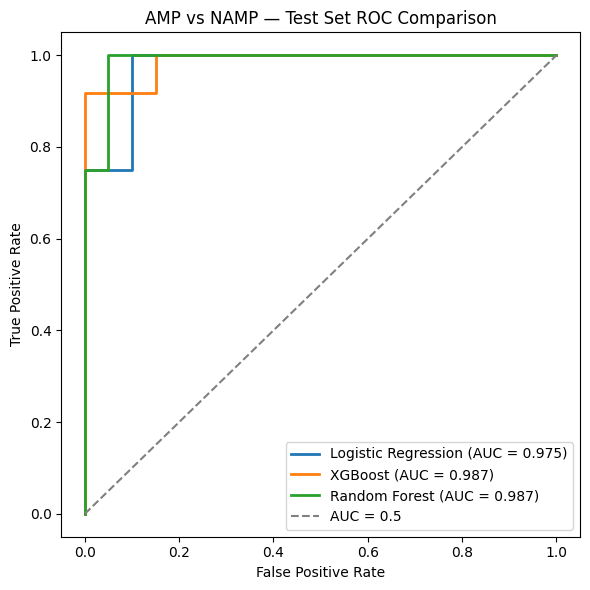

In [21]:
y_proba_logreg = best_lr.predict_proba(X_test)[:, 1]   # Logistic Regression
y_proba_xgb    = best_xgb.predict_proba(X_test)[:, 1]    # XGBoost
y_proba_rf     = best_rf.predict_proba(X_test)[:, 1]     # Random Forest

figure=plot_roc_curve(
    y_true=y_test,
    y_proba_dict={
        "Logistic Regression": y_proba_logreg,
        "XGBoost": y_proba_xgb,
        "Random Forest": y_proba_rf,
    },
    title="AMP vs NAMP — Test Set ROC Comparison",
    save_path=save_dir+"roc_comparison.png",
)

In [22]:
"""
Confusion matrix and model-comparison visualization utilities.

Companion to plot_roc_curve.py - same pattern of "pass in a dict of
{model_name: predictions/probabilities}" so a single call can plot one
model or compare several (LogReg / XGBoost / RF) side by side.
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    f1_score,
    roc_auc_score,
)


def plot_confusion_matrices(y_true, y_pred_dict, class_names=("NAMP", "AMP"), save_path=None):
    """
    Plot one confusion matrix heatmap per model, side by side.

    Parameters
    ----------
    y_true : array-like
        True binary labels (0/1) for the evaluation set.
    y_pred_dict : dict[str, array-like]
        Maps a model name to its predicted class labels, e.g.
        {"Logistic Regression": y_pred_logreg, "XGBoost": y_pred_xgb}.
    class_names : tuple[str, str]
        Display names for (negative_class, positive_class), i.e. (0, 1).
    save_path : str or None
        If given, saves the figure to this path.

    Returns
    -------
    matplotlib.figure.Figure
    """
    n_models = len(y_pred_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
    if n_models == 1:
        axes = [axes]

    for ax, (model_name, y_pred) in zip(axes, y_pred_dict.items()):
        cm = confusion_matrix(y_true, y_pred)
        im = ax.imshow(cm, cmap="Blues")

        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(class_names)
        ax.set_yticklabels(class_names)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(model_name)

        # Annotate each cell with its count, using a readable text color
        # based on how dark that cell's background is.
        thresh = cm.max() / 2.0
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(
                    j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    fontsize=12,
                )
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150)
    plt.show()
    return fig


# def plot_precision_recall_curves(y_true, y_proba_dict, title="Precision-Recall Curve", save_path=None):
#     """
#     Plot precision-recall curves for one or more models on the same axes.
#     More informative than ROC when classes are imbalanced, since it
#     doesn't reward correctly predicting the majority class as heavily.

#     Parameters
#     ----------
#     y_true : array-like
#         True binary labels (0/1) for the evaluation set.
#     y_proba_dict : dict[str, array-like]
#         Maps a model name to its predicted probabilities for the
#         positive class.
#     """
#     fig, ax = plt.subplots(figsize=(6, 6))

#     # Baseline = fraction of positives in the test set (what a
#     # no-skill classifier would score on precision).
#     baseline = np.mean(y_true)

#     for model_name, y_proba in y_proba_dict.items():
#         precision, recall, _ = precision_recall_curve(y_true, y_proba)
#         ap = average_precision_score(y_true, y_proba)
#         ax.plot(recall, precision, linewidth=2, label=f"{model_name} (AP = {ap:.3f})")

#     ax.axhline(baseline, linestyle="--", color="gray", label=f"No-skill baseline ({baseline:.2f})")
#     ax.set_xlabel("Recall")
#     ax.set_ylabel("Precision")
#     ax.set_title(title)
#     ax.legend(loc="lower left")
#     fig.tight_layout()

#     if save_path:
#         fig.savefig(save_path, dpi=150)
#     plt.show()
#     return fig


# def plot_metrics_comparison(y_true, y_pred_dict, y_proba_dict, save_path=None):
#     """
#     Grouped bar chart comparing Accuracy, Balanced Accuracy, MCC, F1,
#     ROC-AUC, and PR-AUC across models.

#     Parameters
#     ----------
#     y_true : array-like
#     y_pred_dict : dict[str, array-like]
#         Predicted class labels per model.
#     y_proba_dict : dict[str, array-like]
#         Predicted positive-class probabilities per model (same keys
#         as y_pred_dict).
#     """
#     metric_names = ["Accuracy", "Balanced Acc.", "MCC", "F1", "ROC-AUC", "PR-AUC"]
#     model_names = list(y_pred_dict.keys())

#     scores = np.zeros((len(model_names), len(metric_names)))
#     for i, name in enumerate(model_names):
#         y_pred = y_pred_dict[name]
#         y_proba = y_proba_dict[name]
#         scores[i] = [
#             accuracy_score(y_true, y_pred),
#             balanced_accuracy_score(y_true, y_pred),
#             matthews_corrcoef(y_true, y_pred),
#             f1_score(y_true, y_pred),
#             roc_auc_score(y_true, y_proba),
#             average_precision_score(y_true, y_proba),
#         ]

#     x = np.arange(len(metric_names))
#     width = 0.8 / len(model_names)

#     fig, ax = plt.subplots(figsize=(10, 5))
#     for i, name in enumerate(model_names):
#         ax.bar(x + i * width, scores[i], width, label=name)

#     ax.set_xticks(x + width * (len(model_names) - 1) / 2)
#     ax.set_xticklabels(metric_names)
#     ax.set_ylim(0, 1.05)
#     ax.set_ylabel("Score")
#     ax.set_title("Test Set Metric Comparison Across Models")
#     ax.legend(loc="lower right")
#     ax.axhline(0, color="black", linewidth=0.8)
#     fig.tight_layout()

#     if save_path:
#         fig.savefig(save_path, dpi=150)
#     plt.show()
#     return fig, scores

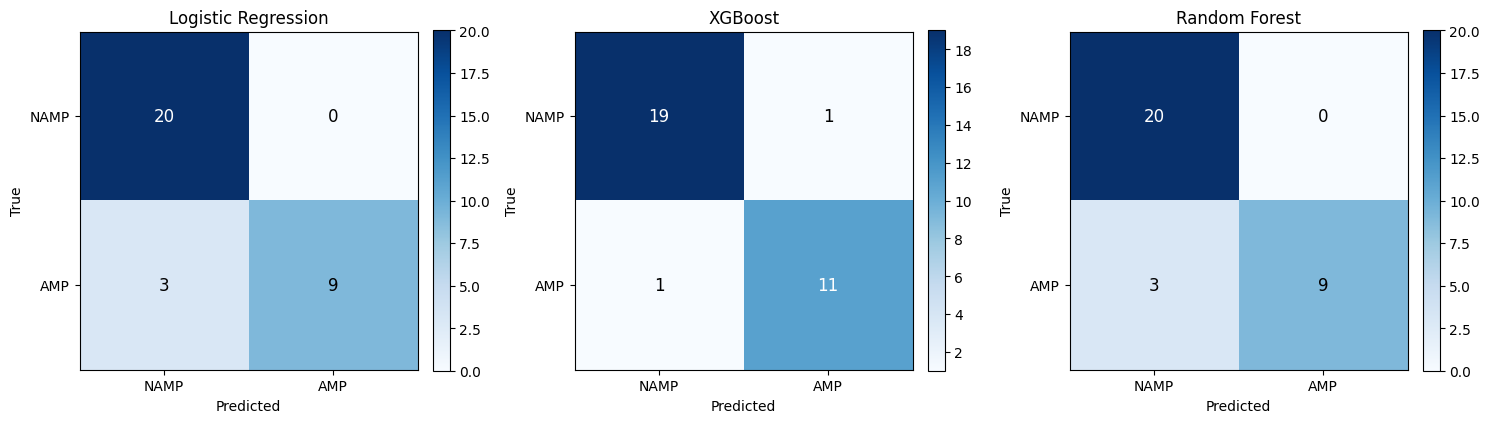

In [23]:
y_pred_dict = {
    "Logistic Regression": best_lr.predict(X_test),
    "XGBoost": best_xgb.predict(X_test),
    "Random Forest": best_rf.predict(X_test),
}
y_proba_dict = {
    "Logistic Regression": best_lr.predict_proba(X_test)[:, 1],
    "XGBoost": best_xgb.predict_proba(X_test)[:, 1],
    "Random Forest": best_rf.predict_proba(X_test)[:, 1],
}

fig = plot_confusion_matrices(y_test, y_pred_dict, save_path=folder_dir+"notebook-output/day-3/confusion_matrices.png")

In [24]:
!pip install -q "transformers==4.46.0" torch accelerate sentencepiece tiktoken

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.2 MB/s eta 0:00:00
Reason for being yanked: This version unfortunately does not work with 3.8 but we did not drop the support yet
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 101.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [25]:
import re
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"✅ GPU detected: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("⚠️ No GPU detected. Execution will be very slow. Check Runtime > Change runtime type.")

def load_protbert(device):
    model_name = "Rostlab/prot_bert"
    print(f"Downloading/Loading {model_name}...")

    # do_lower_case=False is required for ProtBERT (it only understands uppercase)
    tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=False, use_fast=False)
    model = AutoModel.from_pretrained(model_name)

    # Move model to GPU and set to evaluation mode
    model = model.to(device)
    model.eval()

    print("Model loaded successfully!")
    return model, tokenizer

model, tokenizer = load_protbert(device)

✅ GPU detected: Tesla T4
Downloading/Loading Rostlab/prot_bert...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/361 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Model loaded successfully!


In [26]:
def _preprocess_sequence(sequence):
    """
    ProtBERT expects amino acids space-separated, and rare/ambiguous
    residues (U, Z, O, B) mapped to X since they aren't in its vocab [1].
    """
    sequence = sequence.upper()
    sequence = re.sub(r"[UZOB]", "X", sequence)
    return " ".join(list(sequence))

@torch.inference_mode() # Disables gradient calculations to save memory and speed up inference
def _embed_token_batch(sequences, model, tokenizer, device):
    """Tokenize, pad, and embed one batch with mask-aware mean pooling."""
    spaced_sequences = [_preprocess_sequence(seq) for seq in sequences]

    inputs = tokenizer(
        spaced_sequences,
        padding=True,
        return_tensors="pt",
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    outputs = model(**inputs)
    emb = outputs.last_hidden_state  # Shape: (batch, seq_len, hidden_dim)

    # Exclude [PAD], [CLS], and [SEP] positions from the pooling average.
    pool_mask = inputs["attention_mask"].clone()
    pool_mask[inputs["input_ids"] == tokenizer.cls_token_id] = 0
    pool_mask[inputs["input_ids"] == tokenizer.sep_token_id] = 0

    pool_mask = pool_mask.unsqueeze(-1).float()       # (batch, seq_len, 1)
    summed = (emb * pool_mask).sum(dim=1)             # (batch, hidden_dim)
    counts = pool_mask.sum(dim=1).clamp(min=1)        # avoid divide-by-zero
    emb_avg = summed / counts

    return emb_avg.cpu()

def embed_peptides(sequences, model, tokenizer, device, batch_size=16, sort_by_length=True):
    """
    Convert a list of N peptide sequences to an (N, embed_dim) embedding matrix.
    """
    order = list(range(len(sequences)))

    # Grouping similar length sequences saves massive amounts of padding memory
    if sort_by_length:
        order.sort(key=lambda i: len(sequences[i]))
    sorted_seqs = [sequences[i] for i in order]

    all_embeddings = []

    print(f"Embedding {len(sequences)} sequences in batches of {batch_size}...")
    for start in range(0, len(sorted_seqs), batch_size):
        batch = sorted_seqs[start:start + batch_size]
        all_embeddings.append(_embed_token_batch(batch, model, tokenizer, device))

    embeddings_sorted = torch.cat(all_embeddings, dim=0)

    # Restore original sequence order
    inverse_order = np.argsort(order)
    embeddings = embeddings_sorted[inverse_order]
    return embeddings.numpy()

def embed_peptide(sequence, model, tokenizer, device):
    """
    Convert a single peptide sequence to its embedding vector.

    Returns
    -------
    np.ndarray of shape (embed_dim,)
    """
    return embed_peptides([sequence], model, tokenizer, device, batch_size=1)[0]

## Example from outside the dataset: Pexiganan

A true out-of-sample test: **Pexiganan** (MSI-78), a well-known magainin-derived antimicrobial peptide (`GIGKFLKKAKAKFGKAFVKILKK`, 23 residues), run through the exact same inference pipeline the trained models expect — reusing the fitted `pca_pipeline` from Day 2 rather than refitting anything, so this test genuinely reflects what the models learned.

**Steps:**
1. Load Pexiganan's precomputed biophysical properties (`Pexiganan_Biophysical_Properties.csv`) and pull out its raw `Sequence`.
2. Reload ProtBERT (`transformers==4.46.0` pinned, `use_fast=False` to avoid the tokenizer bug hit earlier) and generate its 1024-dim embedding via `embed_peptide`.
3. Load the **already-fitted** `pca_pipeline` from Day 2 via `joblib.load` and call `.transform()` only (never refit) — this is what keeps the reduced embedding on the same 76-dimensional basis the models were trained on.
4. Drop the same 6 features (`NonpolarResidues_pct`, `HydrophobicRatio`, `AliphaticIndex`, `HydrophobicMoment`, `Charge_pH7`, `TinyResidues_pct`) from Pexiganan's biophysical properties, matching the curated feature set used in training.
5. Concatenate curated biophysical features + 76 reduced embedding dimensions into one row (97 columns including `ID`/`Sequence`, 95 after dropping them) — matching the training feature schema exactly.
6. Predict with all three trained models.

In [27]:
pexignan_file_path = folder_dir+'Pexiganan_Biophysical_Properties.csv'
pexignan_df = pd.read_csv(pexignan_file_path)
pexignan_df

model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

,ID,Sequence,MW,Length,pI,Charge_pH7,GRAVY,Aromaticity,InstabilityIndex,AliphaticIndex,...,PositiveResidues_pct,NegativeResidues_pct,PolarResidues_pct,NonpolarResidues_pct,TinyResidues_pct,SmallResidues_pct,SulfurResidues_pct,Proline_pct,Glycine_pct,Cysteine_pct
0,Pexiganan,GIGKFLKKAKAKFGKAFVKILKK,2549.236,23,10.903,8.995,-0.0739,0.1304,-5.461,93.478,...,39.13,0,0,60.87,26.09,26.09,0,0,13.04,0


In [28]:
pexignan_df

,ID,Sequence,MW,Length,pI,Charge_pH7,GRAVY,Aromaticity,InstabilityIndex,AliphaticIndex,...,PositiveResidues_pct,NegativeResidues_pct,PolarResidues_pct,NonpolarResidues_pct,TinyResidues_pct,SmallResidues_pct,SulfurResidues_pct,Proline_pct,Glycine_pct,Cysteine_pct
0,Pexiganan,GIGKFLKKAKAKFGKAFVKILKK,2549.236,23,10.903,8.995,-0.0739,0.1304,-5.461,93.478,...,39.13,0,0,60.87,26.09,26.09,0,0,13.04,0


In [29]:
pexignan_seq = pexignan_df.at[0, 'Sequence']
pexignan_seq

'GIGKFLKKAKAKFGKAFVKILKK'

In [36]:
embeddings.reshape(-1, 1).shape

(1024, 1)

In [37]:
import joblib

embeddings = embed_peptide(pexignan_seq, model, tokenizer, device)

pca_pipeline = joblib.load(folder_dir+'notebook-output/day-2/pca_pipeline.joblib')
reduced_embeddings = pca_pipeline.transform(embeddings.reshape(1, 1024))
reduced_embeddings

Embedding 1 sequences in batches of 1...


array([[ 12.415365  ,   1.2756424 ,  19.05941   , -13.722124  ,
         -3.2658315 ,   6.924196  ,   7.414385  ,   3.4552782 ,
          7.229125  ,   2.6583776 , -10.632779  ,   3.1472123 ,
         -2.8707302 ,   3.2037575 ,  -6.0194464 ,  -3.5351887 ,
         -1.3967726 ,  -6.3766294 ,  -3.8386528 ,   0.19023445,
          4.4383187 ,   1.0107987 ,   4.6314135 ,  -1.5903126 ,
          0.2992412 ,  -1.7783455 ,   2.6244917 ,   1.3217897 ,
          1.5993844 ,   2.6587334 ,   4.4480147 ,   1.3052365 ,
          4.105679  ,  -1.8579295 ,  -1.1864529 ,   1.8364258 ,
         -0.94031906,   3.0671782 ,  -3.494546  ,   1.585198  ,
         -3.6121213 ,   3.184752  ,   1.9303789 ,  -3.579974  ,
         -3.3335822 ,   7.802922  ,   0.25787053,  -0.12850961,
         -1.0104856 ,   1.7782103 ,   1.4264511 ,   1.5328574 ,
          1.3418071 ,   1.2831676 ,   1.0502111 ,   0.5362795 ,
         -0.40513   ,   1.5735872 ,  -1.2185597 ,   1.5453453 ,
         -2.2005684 ,  -0.24711551,   1.

In [40]:
reduced_embedding_df = pd.DataFrame(reduced_embeddings, columns=[f'reduced_{i}' for i in range(reduced_embeddings.shape[1])])

In [42]:
reduced_embedding_df

,reduced_0,reduced_1,reduced_2,reduced_3,reduced_4,reduced_5,reduced_6,reduced_7,reduced_8,reduced_9,...,reduced_66,reduced_67,reduced_68,reduced_69,reduced_70,reduced_71,reduced_72,reduced_73,reduced_74,reduced_75
0,12.415365,1.275642,19.05941,-13.722124,-3.265831,6.924196,7.414385,3.455278,7.229125,2.658378,...,-3.156093,0.357111,-1.983643,-2.753994,-2.146625,0.139182,-1.333264,-1.419707,-2.791565,0.06688


In [43]:
features_to_drop = ['NonpolarResidues_pct', 'HydrophobicRatio', 'AliphaticIndex', 'HydrophobicMoment', 'Charge_pH7', 'TinyResidues_pct']
pexignan_biophysical_df = pexignan_df.drop(columns=features_to_drop)
pexignan_biophysical_df

,ID,Sequence,MW,Length,pI,GRAVY,Aromaticity,InstabilityIndex,BomanIndex,HelixFraction,...,SheetFraction,ShannonEntropy,PositiveResidues_pct,NegativeResidues_pct,PolarResidues_pct,SmallResidues_pct,SulfurResidues_pct,Proline_pct,Glycine_pct,Cysteine_pct
0,Pexiganan,GIGKFLKKAKAKFGKAFVKILKK,2549.236,23,10.903,-0.0739,0.1304,-5.461,0.393,0.6087,...,0.3478,2.489,39.13,0,0,26.09,0,0,13.04,0


In [45]:
pexignan_final_df = pd.concat([pexignan_biophysical_df, reduced_embedding_df], axis=1)
pexignan_final_df

,ID,Sequence,MW,Length,pI,GRAVY,Aromaticity,InstabilityIndex,BomanIndex,HelixFraction,...,reduced_66,reduced_67,reduced_68,reduced_69,reduced_70,reduced_71,reduced_72,reduced_73,reduced_74,reduced_75
0,Pexiganan,GIGKFLKKAKAKFGKAFVKILKK,2549.236,23,10.903,-0.0739,0.1304,-5.461,0.393,0.6087,...,-3.156093,0.357111,-1.983643,-2.753994,-2.146625,0.139182,-1.333264,-1.419707,-2.791565,0.06688


In [46]:
X = pexignan_final_df.drop(columns=['Sequence', 'ID']).to_numpy()

In [48]:
y_pred_dict = {
    "Logistic Regression": best_lr.predict(X),
    "XGBoost": best_xgb.predict(X),
    "Random Forest": best_rf.predict(X),
}

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [49]:
y_pred_dict

{'Logistic Regression': array([0]),
 'XGBoost': array([0]),
 'Random Forest': array([0])}

**Result:** all three models — Logistic Regression, XGBoost, and Random Forest — predicted **NAMP (0)** for Pexiganan.

**This is a real misclassification, not a technicality.** Pexiganan is a genuine, well-studied antimicrobial peptide, so a true label of AMP would be expected. This is worth investigating rather than glossing over — a natural next step given the Length/MW-heavy feature importance seen in both tree models above is to check whether Pexiganan's length (23 aa) and molecular weight (2549 Da) fall outside the typical range the models saw for AMPs in training, which would point toward the earlier concern about `Length`/`MW` reflecting a dataset-construction pattern more than a robust biological rule.